# Introducción a PyTorch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/intro_pytorch.ipynb)

## Parte 1: Tensores

Un tensor es un objeto matemático que generaliza conceptos como escalares, vectores y matrices para representar relaciones entre múltiples direcciones en un espacio.

En Aprendizaje automático profundo, lo vamos a utilizar como sinónimo de **array multidimensional**. 

El escalar es un tensor de orden 0, un vector es un tensor de orden 1, una matriz uno de orden 2, y podemos generalizarlo para un tensor de orden n. 

Un tensor tiene componentes y transforma de manera especifica. En PyTorch, existen muchas maneras diferentes de crear tensores y un conjunto amplio de métodos y funciones para operar con ellos. Algunas funciones para generar tensores:

In [1]:
import torch

# Desde lista
a = torch.tensor([1, 2, 3])

# Ceros / unos
b = torch.zeros(2, 3)
c = torch.ones(2, 3)

# Aleatorio
d = torch.rand(2, 3)

# Rango
e = torch.arange(0, 10)

### Propiedades básicas de los tensores en PyTorch

In [3]:
# imprimir tamaño, tipo de dato y dispositivo
print(a.shape)      # tamaño
print(a.dtype)      # tipo de dato
print(a.device)     # CPU o GPU

torch.Size([3])
torch.int64
cpu


### Operaciones básicas

Podemos hacer aritmética elemento a elemento entre tensores:

In [7]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

# hacer x + y, x - y, x * y, x / y
print(x + y)  # suma
print(x - y)  # resta
print(x * y)  # multiplicación
print(x / y)  # división

tensor([5., 7., 9.])
tensor([-3., -3., -3.])
tensor([ 4., 10., 18.])
tensor([0.2500, 0.4000, 0.5000])


También permite directamente la operación con escalares de manera intuitiva y sencilla

In [8]:
x * 2

tensor([2., 4., 6.])

In [9]:
y + 10

tensor([14., 15., 16.])

Una operación muy importante y utilizada en PyTorch es el `boradcasting` en donde se expanden dimensiones de tensores para poder operar con ellos automáticamente (siempre tener cuidado con esto)

In [17]:
x = torch.randint(0, 10, (2, 3))
print('x:', x)
print('x.shape:', x.shape)

y = torch.randint(0, 10, (3,))
print('y:', y)
print('y.shape:', y.shape)

z = x + y  # y se “expande”
print(z)

x: tensor([[2, 7, 8],
        [5, 5, 1]])
x.shape: torch.Size([2, 3])
y: tensor([6, 2, 4])
y.shape: torch.Size([3])
tensor([[ 8,  9, 12],
        [11,  7,  5]])


El broadcasting sucede para todas las operaciones básicas.

También podemos elegir elementos de tensores mediante índices y lo que se conoce como `slicing`

In [21]:
x = torch.tensor([[1, 2, 3, 5],
                  [4, 5, 6, 7]])

print(x[0, 1])     # 2
print(x[:, 1])     # columna
print(x[1, :])     # fila
print(x[1, 0:2])  # elementos 0 y 1 de la fila 1
print(x[1,0::2]) # elementos 0 y 2 de la fila 1

tensor(2)
tensor([2, 5])
tensor([4, 5, 6, 7])
tensor([4, 5])
tensor([4, 6])


Cuando tratamos con multiplicaciones matriciales, existe tanto función como operación básica que permite realizar la operación:

In [24]:
A = torch.rand(2, 3)
B = torch.rand(3, 4)

C = torch.matmul(A, B)

C_bis = A @ B

print(C)
print(C_bis)
print(torch.allclose(C, C_bis)) 

tensor([[1.2335, 1.3969, 1.1392, 1.8715],
        [1.0250, 1.4183, 1.1348, 1.4496]])
tensor([[1.2335, 1.3969, 1.1392, 1.8715],
        [1.0250, 1.4183, 1.1348, 1.4496]])
True


También podemos obtener la transpuesta de una matriz fácilmente con

In [25]:
A.T

tensor([[0.2911, 0.9550],
        [0.8669, 0.4962],
        [0.9633, 0.1489]])

### Métodos implícitos en tensores muy útiles

Los tensores de PyTorch también tienen métodos inherentes que permiten operaciones sencillas muy utilizadas, como la suma de las componentes, el valor medio, máximo, mínimo, desvío estándar, etc. Estas operaciones se pueden hacer para todo el tensor o para algunas componentes del mismo, seleccionando la dimensión sobre la cuál se desea hacer.

In [29]:
x = torch.rand(2, 3)
print(x)

print('suma', x.sum())
print('media', x.mean())
print('máximo', x.max())
print('mínimo', x.min())
print('desviación estándar', x.std())

# por dimensión
print('suma por columnas', x.sum(dim=0))
print('media por filas', x.mean(dim=1))

tensor([[0.2407, 0.7426, 0.2729],
        [0.7252, 0.7869, 0.3378]])
suma tensor(3.1060)
media tensor(0.5177)
máximo tensor(0.7869)
mínimo tensor(0.2407)
desviación estándar tensor(0.2589)
suma por columnas tensor([0.9659, 1.5295, 0.6107])
media por filas tensor([0.4187, 0.6166])


### Cambiar forma

A veces es necesario ver a los datos en distintas representaciones tensoriales.  

In [30]:
x = torch.arange(6)

x = x.reshape(2, 3)
print(x)

tensor([[0, 1, 2],
        [3, 4, 5]])


In [32]:
x.view(3,2)

tensor([[0, 1],
        [2, 3],
        [4, 5]])

### Concatenación

a veces resulta importante unir dos tensores de manera específica para representarlos en un tensor de mayor dimensión

In [36]:
a = torch.rand(2, 3)
b = torch.rand(2, 3)

print('concatenación por filas \n', torch.cat([a, b], dim=0))
print('concatenación por columnas \n', torch.cat([a, b], dim=1))

concatenación por filas 
 tensor([[0.7089, 0.8001, 0.4241],
        [0.2969, 0.1895, 0.7835],
        [0.4591, 0.4791, 0.7974],
        [0.4516, 0.8575, 0.8836]])
concatenación por columnas 
 tensor([[0.7089, 0.8001, 0.4241, 0.4591, 0.4791, 0.7974],
        [0.2969, 0.1895, 0.7835, 0.4516, 0.8575, 0.8836]])


tabién se puede lograr con hstack y vstack

In [38]:
print('concatenación por filas \n', torch.vstack([a, b]))  # filas
print('concatenación por columnas \n', torch.hstack([a, b]))  # columnas

concatenación por filas 
 tensor([[0.7089, 0.8001, 0.4241],
        [0.2969, 0.1895, 0.7835],
        [0.4591, 0.4791, 0.7974],
        [0.4516, 0.8575, 0.8836]])
concatenación por columnas 
 tensor([[0.7089, 0.8001, 0.4241, 0.4591, 0.4791, 0.7974],
        [0.2969, 0.1895, 0.7835, 0.4516, 0.8575, 0.8836]])


### Cambio de dispostivo dónde realizar los cómputos

A veces querremos trabajar con los procesadores de la GPU. Para esto, todo tensor involucrado en la operación debe estar previamente en la GPU. PyTorch ofrece el método `.to()` para mover tensores de la CPU a la GPU de manera sencilla. 

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x = torch.rand(3, 3).to(device)
print(x.device)

cpu


In [54]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

Usando: cpu


In [53]:
N = 3000
A_cpu = torch.rand(N, N)
B_cpu = torch.rand(N, N)

# ---- CPU timing ----
start = time.perf_counter()
C_cpu = A_cpu @ B_cpu
end = time.perf_counter()

cpu_time = end - start
print(f"CPU time: {cpu_time:.4f} seconds")

if torch.cuda.is_available():
    # ---- GPU timing ----
    A_gpu = A_cpu.to(device)
    B_gpu = B_cpu.to(device)

    # Warm-up: evita medir la sobrecarga de la primera operación en GPU
    _ = A_gpu @ B_gpu
    torch.mps.synchronize()

    start = time.perf_counter()
    C_gpu = A_gpu @ B_gpu
    torch.mps.synchronize()
    end = time.perf_counter()

    gpu_time = end - start
    print(f"GPU time: {gpu_time:.4f} seconds")
    print(f"Speedup: {cpu_time / gpu_time:.2f}x")
else:
    print("GPU no disponible, solo se midió el tiempo en CPU.")


CPU time: 0.0648 seconds
GPU no disponible, solo se midió el tiempo en CPU.


### Expandir o aplastar tensores

A veces necesitamos una dimensión de más o una de menos. Esto se puede modificar con los métodos `.squeeze()` y `unsqueeze()`. Cuando hacemos unsqueeze, hay que indicarle en qué posición del tensor vamos a agregar una nueva dimensión. Cuando hacemos squeeze, sólo comprime aquellas dimensiones que tenga una sola componente.

In [126]:
x = torch.tensor([1.0, 2.0, 3.0])
x_expandido = x.unsqueeze(0)  # añade dimensión al inicio
print(x_expandido.shape)
print(x_expandido.unsqueeze(2).shape)
print(x_expandido.shape)
print(x_expandido.squeeze().shape)

torch.Size([1, 3])
torch.Size([1, 3, 1])
torch.Size([1, 3])
torch.Size([3])


## Grafos computacionales dinámicos: gráfos acíclicos direccionados

En PyTorch, podemos definir que un tensor mantenga información de cómo cambia el resultado final de una operación que involucra este tensor, con respecto a este tensor. Para ello almacenamos junto al tensor, su gradiente calculado. Esto se puede hacer de la siguiente manera: 

In [114]:
x = torch.tensor([3.0], requires_grad=True)
y = x**2
z = 7*y

Luego de esta operación, como `requires_grad=True`, PyTorch construye un grafo acíclico direccionado, que mantiene la relación

$$
x \rightarrow y=x^2 \rightarrow z=7y
$$

donde en cada operación se guarda como se calculó y como derivar respecto a la variable, siguiendo al regla de la cadena.

In [115]:
#dy/dx = 2x, si x=3, dy/dx = 6
y.backward(retain_graph=True) #dy/dx se almacena en x.grad
print(x.grad)

tensor([6.])


Recordar resetear el gradiente en el medio, sino se acumulan los valores

In [116]:
x.grad.zero_()
z.backward() #dz/dx = dz/dy * dy/dx = 7 * 2*3 = 42
print(x.grad)

tensor([42.])


Veamos un ejemplo cuando tenemos más que un escalar, en este caso ya se trabaja con un jacobiano

In [ ]:
x = torch.tensor([ 3.0, 2.0], requires_grad=True)
y = x * 2
z = y.sum()
z.backward()
print(x.grad)

tensor([2., 2.])


Lo mismo si tenemos distintas variables

In [ ]:
# Creat tensores
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
# realizar una operación
z = x * y + y ** 2
# retropropagación
z.backward()
# Gradientes
def mostrar_gradientes():
    print(f'dz/dx: {x.grad}')  # Output: 3.0
    print(f'dz/dy: {y.grad}')  # Output: 8.0
mostrar_gradientes()

dz/dx: 3.0
dz/dy: 8.0


En este ejemplo, PyTorch construye un gráfico dinámico a medida que se van ejecutando las operaciones. la función `backward()` computa los gradientes automáticamente utilizando el grafo. Una vez que se utilizó para computar el gradiente, el grafo es eliminado de la memoria, a menos que se explicite lo contrario. 

---
# Parte 2: Loop de entrenamiento en PyTorch

En esta parte vamos a ver el loop de entrenamiento completo en `PyTorch` que utilizaremos a lo largo de la materia.  


### Datos
Por un lado necesitaremos un conjunto de datos (sean sintéticos para que sean ilustrativos o una base de datos real) de la cuál podamos aprender. Todos los modelos que veremos son centrados en los datos (data-centric), pero veremos más adelante cómo hacer para incluir conocimiento de los sitemas bajo estudio en el aprendizaje. Sin embargo, seguiremos siempre aprendiendo y pesando fuertemente la componente de ajuste a los datos observados.

En este caso, generaremos datos utilizando una `funcion_compleja` que presenta un comportamiento suficientemente complejo como para ajustarlo con modelos lineales o no lineales sencillos de pocos parámetros. 

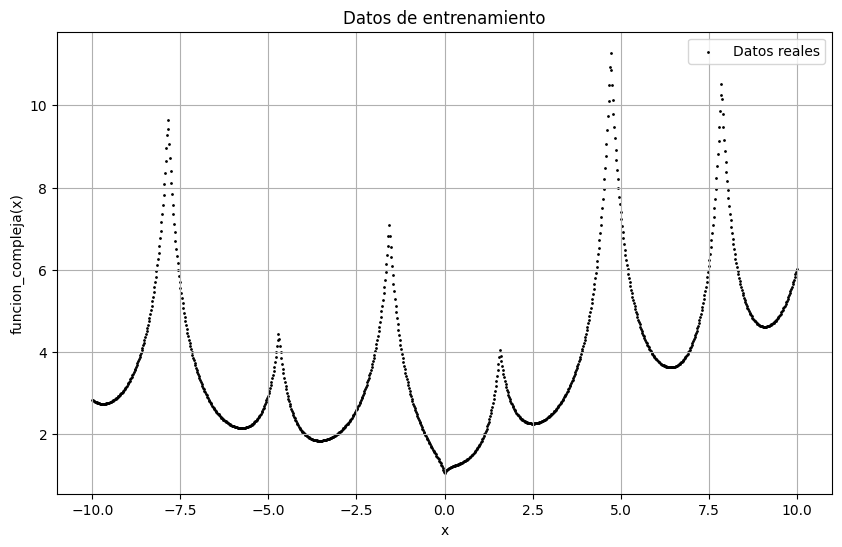

In [259]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


# ===========================================================
# 1. Generación de datos
# ===========================================================
def funcion_compleja(x):
    return (
        np.abs(x) ** 0.5
        + 0.1 * x
        + 0.01 * x**2
        + 1
        - np.sin(x)
        + 0.5 * np.exp(x / 10.0)
    ) / (0.5 + np.abs(np.cos(x)))

N = 1_000
xdata = np.linspace(-10, 10, N).reshape(-1, 1).astype(np.float32)
ydata = funcion_compleja(xdata).astype(np.float32)

plt.figure(figsize=(10, 6))
plt.scatter(xdata, ydata, color="black", label="Datos reales", s=1)
plt.xlabel("x")
plt.ylabel("funcion_compleja(x)")
plt.title("Datos de entrenamiento")
plt.legend()
plt.grid(True)
# Pasamos a tensores de PyTorch
X = torch.from_numpy(xdata)
Y = torch.from_numpy(ydata)

una vez obtenido el conjunto de datos, nos preguntamos qué tipo de problema queremos resolver. En este caso, podríamos entrenar una red neuronal tipo perceptrón multicapa que aprenda los datos $y$ en función de $x$, es decir un problema de regresión de una variable. En este caso vamos a poner a prueba el teorema de aproximación universal, que establece que, dada una función $f$ continua, existe una red neuronal del tipo MLP de 1 capa tal que puede aproximar. Ojo, el teorema no dice cuál es la red ni cuántas neuronas harán falta, sino que establece la existencia. Podemos probar con distintas arquitecturas de MLP y de paso aprender como fuciona loop de entrenamiento de un modelo en PyTorch.

A continuación, muestro dos maneras en las que se pueden particionar los datos en conjuntos de entrenamiento y de prueba. Esto es un procedimiento usual en el aprendizaje automático, ya que es necesario probar los modelos en datos que no fueron utilizados para entrenarlo. En realidad, se estila separar al conjunto de datos en 3 conjuntos: uno de entrenamiento, otro de validación, y uno final de prueba. El de entrenamiento se utiliza para entrenar el modelo, es decir actualizar los parámetros del mismo con tal de minimizar la función de costo. El de validación se suele utilizar dentro del loop de entrenamiento, para tomar decisiones también, como elegir hiperparámetros del modelo, hacerlo early-stopping, o inclusive comparar modelos. En este caso, no entrenamos a los modelos con estos datos, pero decidimos cuál modelo utilizar en base a cómo se comportan frente a estos datos. Finalmente, se utiliza el conjunto de prueba para poner a prueba el modelo final elegido ante datos nunca antes visto.  

In [265]:
from torch.utils.data import random_split

dataset = TensorDataset(X, Y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, val_dataset, test_dataset = random_split(dataset=dataset, 
                                           lengths=[train_size, int(test_size*0.8), int(test_size*0.2)],  
                                           generator=torch.Generator().manual_seed(42))

### DataLoader y batches

Contamos con una base de datos que tienen 1000 puntos. Para entrenar, podríamos pasar todos los datos por el modelo. Esto se llama una época. Luego, podríamos calcular la función de costo considerando todos los resultados obtenidos en la época, luego hacer la retropropagación y obtener una estimación del gradiente para el conjunto de parámetros $w$ de la red y tomar la decisión de cómo actualizarlos como hemos visto en al teoría. Esto puede resultar muy costoso y lento, ya que para realizar una actualización en el espacio de los parámetros de la red, debemos ver a todos los datos de la época! El concepto de mini-batch consiste en pensar que podemos aproximar al gradiente con menos cantidad de puntos que el conjunto total de datos, y que esa estimación es suficiente como para encontrar una actualización razonable de los pesos. De esta manera, podríamos realizar varias actualizaciones de pesos por época, y así converger más rápido.

`DataLoader` en PyTorch es la herramienta que se encarga de entregar los datos al modelo durante el entrenamiento de forma eficiente y organizada. DataLoader toma un `Dataset` de PyTorch y lo convierte en un iterador de batches, con tamaño de batch determinado en `batch_size`. También se encarga de mezclar los datos si `shuffle=True`. También es capaz de utilizar múltiples procesos para cargar los datos, lo que acelera el entrenamiento con grandes bases de datos.

In [ ]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

### Definición de modelo

In [ ]:
class MLP1D(nn.Module):
    def __init__(self, input_dim, nb_layers=3, nb_nodes=20):
        super().__init__()

        layers = []
        layers.append(nn.Linear(input_dim, nb_nodes))
        layers.append(nn.ReLU())

        for _ in range(nb_layers - 1):
            layers.append(nn.Linear(nb_nodes, nb_nodes))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(nb_nodes, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


nb_layers = 1
nb_nodes = 200
epochs = 4_000
save_period = 400
learning_rate = 2e-3
saved_epochs = list(range(save_period, epochs + 1, save_period))

model = MLP1D(input_dim=X.shape[1], nb_layers=nb_layers, nb_nodes=nb_nodes)
print(model)

MLP1D(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1, bias=True)
  )
)


In [302]:
# ===========================================================
# 4. Función de pérdida y optimizador
# ===========================================================
criterion = nn.HuberLoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)

In [303]:
# ===========================================================
# 5. Entrenamiento
# ===========================================================
def entrenar_modelo(modelo, train_loader, val_loader, criterion, optimizer, epochs=1000, saved_epochs=[200, 500, 1000]):
    loss_history = []
    val_loss_history = []
    saved_predictions = {}

    for epoch in range(1, epochs + 1):
        modelo.train()   # modo entrenamiento
        epoch_loss = 0.0

        for xb, yb in train_loader:
            # ---- paso 1: resetear gradientes acumulados
            optimizer.zero_grad()

            # ---- paso 2: forward
            y_pred = modelo(xb)

            # ---- paso 3: calcular pérdida
            loss = criterion(y_pred, yb)

            # ---- paso 4: backward
            loss.backward()

            # ---- paso 5: actualizar parámetros
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(dataset)
        loss_history.append(epoch_loss)

        modelo.eval() # Pasar a evaluación para fijar capas estocásticas como dropout o batchnorm
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dataset:
                y_pred = modelo(xb)
                loss = criterion(y_pred, yb)
                val_loss += loss.item() * xb.size(0)

        val_loss /= len(val_dataset)
        val_loss_history.append(val_loss)

        if epoch % 500 == 0:
            print(f"Época {epoch:03d} | {criterion.__class__.__name__} entrenamiento: {epoch_loss:.6f} | {criterion.__class__.__name__} Prueba: {val_loss:.6f}")

        # Guardamos snapshots del modelo para mostrar cómo mejora el ajuste
        if epoch in saved_epochs:
            with torch.no_grad():
                y_snapshot = model(val_dataset[:][0]).cpu().numpy().squeeze()
            saved_predictions[epoch] = y_snapshot.copy()
    return loss_history, val_loss_history, saved_predictions

loss_history, val_loss_history, saved_predictions = entrenar_modelo(model, train_loader, val_dataset, criterion, optimizer, epochs=epochs, saved_epochs=saved_epochs)

Época 500 | HuberLoss entrenamiento: 0.388737 | HuberLoss Prueba: 0.552574
Época 1000 | HuberLoss entrenamiento: 0.299045 | HuberLoss Prueba: 0.447057
Época 1500 | HuberLoss entrenamiento: 0.293907 | HuberLoss Prueba: 0.434477
Época 2000 | HuberLoss entrenamiento: 0.293894 | HuberLoss Prueba: 0.408915
Época 2500 | HuberLoss entrenamiento: 0.272214 | HuberLoss Prueba: 0.519142
Época 3000 | HuberLoss entrenamiento: 0.275641 | HuberLoss Prueba: 0.381916
Época 3500 | HuberLoss entrenamiento: 0.264012 | HuberLoss Prueba: 0.356694
Época 4000 | HuberLoss entrenamiento: 0.254662 | HuberLoss Prueba: 0.655148


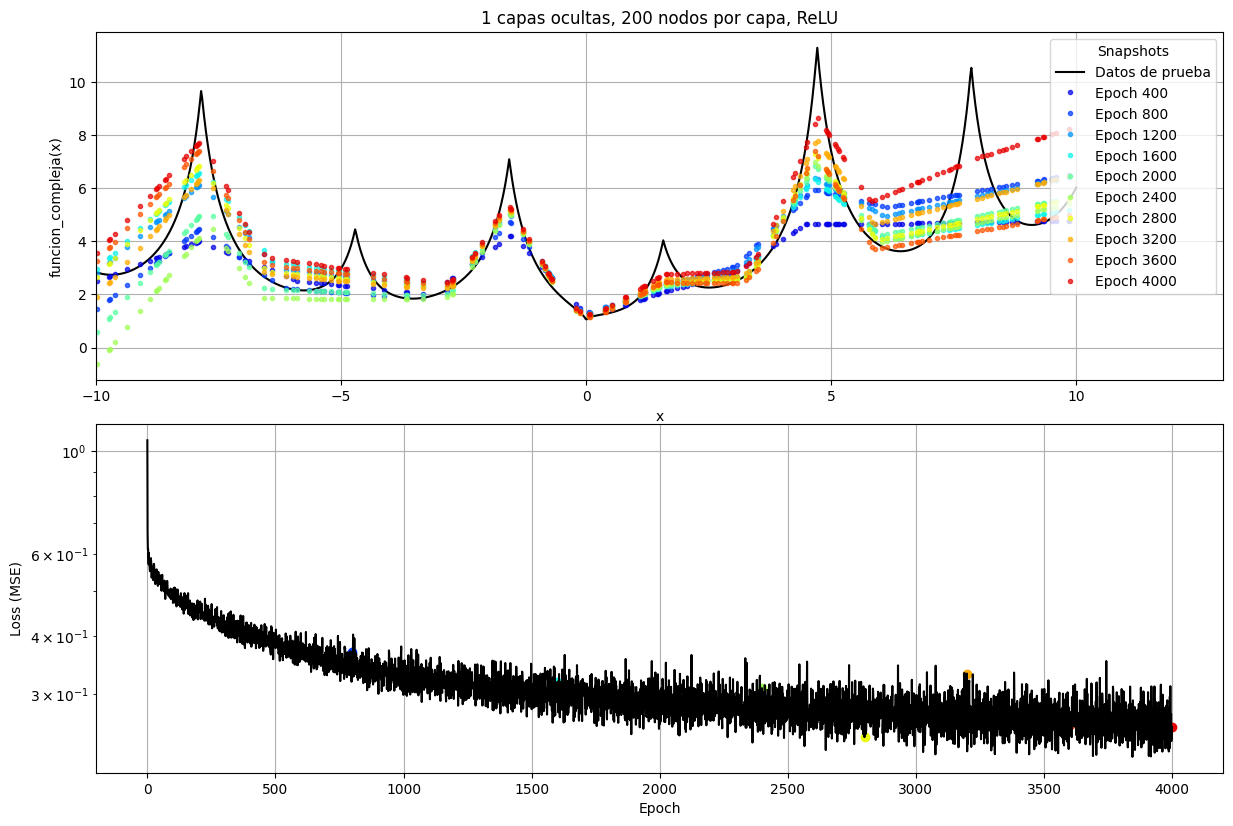

In [304]:
# ===========================================================
# 6. Gráficos
# ===========================================================
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8))
plt.tight_layout()

# Datos reales
ax1.plot(xdata, ydata, color="black", label="Datos de prueba")

# Colores para snapshots
colors = [plt.cm.jet((i + 1) / float(len(saved_epochs) + 1)) for i in range(len(saved_epochs))]

# Curvas predichas en distintos momentos del entrenamiento
for i, epoch in enumerate(saved_epochs):
    ax1.plot(val_dataset[:][0], saved_predictions[epoch], 'o', color=colors[i], label=f"Epoch {epoch}", ms=3, alpha=0.7)
    ax2.plot(epoch, loss_history[epoch - 1], color=colors[i], marker="o")

ax1.set_title(f"{nb_layers} capas ocultas, {nb_nodes} nodos por capa, ReLU")
ax1.set_xlabel("x")
ax1.set_ylabel("funcion_compleja(x)")
ax1.set_xlim(-10, 13)
ax1.grid(True)
ax1.legend(loc="upper right", title="Snapshots")

# Historia de la loss
ax2.plot(loss_history, color="black")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss (MSE)")
ax2.set_yscale("log")
ax2.grid(True)

plt.show()

Entrenando con MSELoss y Adam
Época 500 | MSELoss entrenamiento: 0.507572 | MSELoss Prueba: 0.532652
Época 1000 | MSELoss entrenamiento: 0.203670 | MSELoss Prueba: 0.218853
Época 1500 | MSELoss entrenamiento: 0.091979 | MSELoss Prueba: 0.125494
Época 2000 | MSELoss entrenamiento: 0.098490 | MSELoss Prueba: 0.076684
Entrenando con MSELoss y SGD
Época 500 | MSELoss entrenamiento: 1.741924 | MSELoss Prueba: 2.604781
Época 1000 | MSELoss entrenamiento: 1.443576 | MSELoss Prueba: 2.118594
Época 1500 | MSELoss entrenamiento: 1.310641 | MSELoss Prueba: 1.826148
Época 2000 | MSELoss entrenamiento: 1.097743 | MSELoss Prueba: 1.552078
Entrenando con MSELoss y RMSprop
Época 500 | MSELoss entrenamiento: 0.548189 | MSELoss Prueba: 0.360436
Época 1000 | MSELoss entrenamiento: 0.210837 | MSELoss Prueba: 0.126508
Época 1500 | MSELoss entrenamiento: 0.111425 | MSELoss Prueba: 0.075845
Época 2000 | MSELoss entrenamiento: 0.107163 | MSELoss Prueba: 0.043024
Entrenando con HuberLoss y Adam
Época 500 | Hub

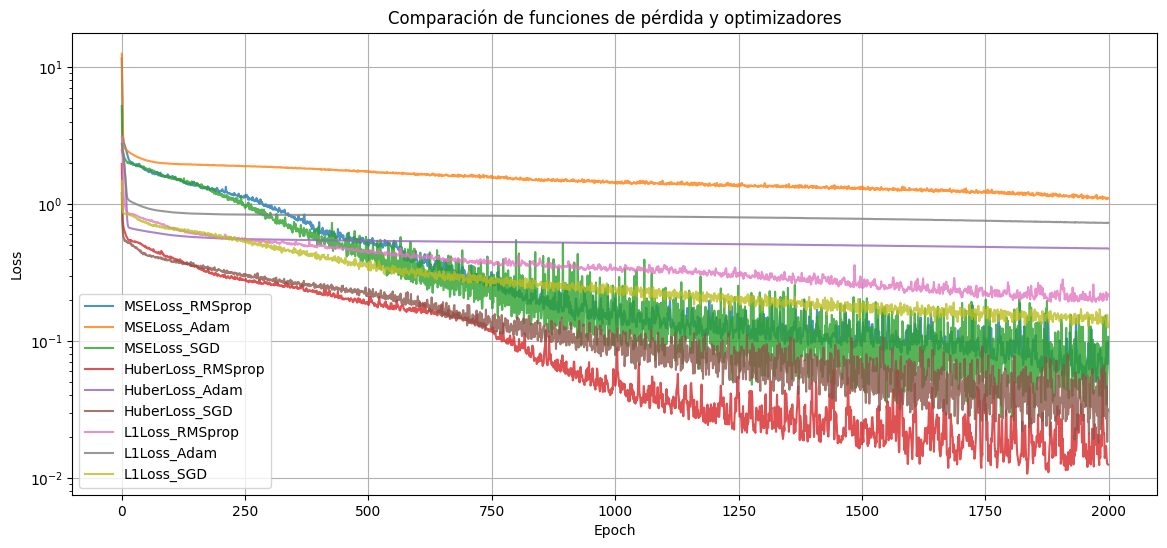

In [336]:
lr = 1e-3
nb_layers = 3
nb_nodes = 30
seed = 30
epochs = 2_000

criterions = [nn.MSELoss, nn.HuberLoss, nn.L1Loss]
optimizers = [lambda params: torch.optim.Adam(params, lr),
              lambda params: torch.optim.SGD(params, lr),
              lambda params: torch.optim.RMSprop(params, lr)]

torch.manual_seed(seed)
models, histories, test_histories, all_saved_predictions = {}, {}, {}, {}
plt.figure(figsize=(14, 6))
for criterion in criterions:
    criterion = criterion()
    for optimizer_fn in optimizers:
        label =f"{criterion.__class__.__name__}_{optimizer.__class__.__name__}"
        models[label] = MLP1D(input_dim=X.shape[1], nb_layers=nb_layers, nb_nodes=nb_nodes)
        optimizer = optimizer_fn(models[label].parameters())
        
        print(f"Entrenando con {criterion.__class__.__name__} y {optimizer.__class__.__name__}")
        histories[label], test_histories[label], all_saved_predictions[label] = entrenar_modelo(models[label], train_loader, val_dataset, criterion, optimizer, epochs=epochs)
        
        plt.plot(histories[label], label=label, alpha=0.8)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparación de funciones de pérdida y optimizadores")
plt.grid(True)
plt.legend()
plt.show()

In [338]:
for label, test_history in test_histories.items():
    print(f"{label}: {test_history[-1]:.6f}")

MSELoss_RMSprop: 0.076684
MSELoss_Adam: 1.552078
MSELoss_SGD: 0.043024
HuberLoss_RMSprop: 0.021050
HuberLoss_Adam: 0.733879
HuberLoss_SGD: 0.017730
L1Loss_RMSprop: 0.232820
L1Loss_Adam: 1.087875
L1Loss_SGD: 0.248645


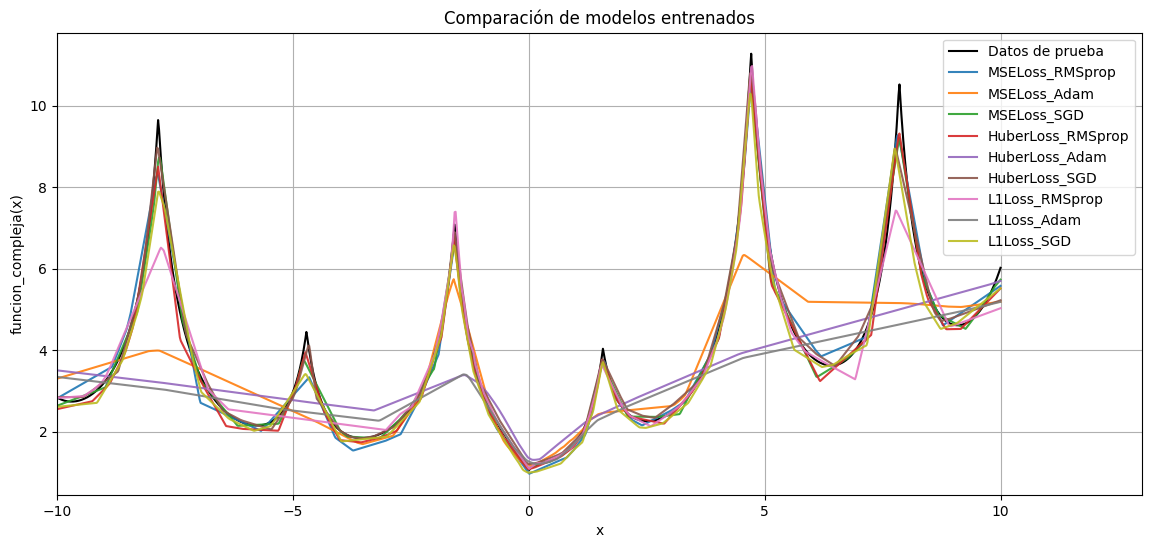

In [339]:
plt.figure(figsize=(14, 6))
plt.plot(xdata, ydata, color="black", label="Datos de prueba")
for label, model in models.items():
    with torch.no_grad():
        y_pred = model(torch.tensor(xdata).float()).cpu().numpy().squeeze()
    plt.plot(xdata, y_pred, label=label, alpha=0.9)
plt.xlabel("x")
plt.ylabel("funcion_compleja(x)")
plt.title("Comparación de modelos entrenados")
plt.xlim(-10, 13)
plt.grid(True)
plt.legend()
plt.show()
    

In [340]:
epochs = 6_000
modelo_final = MLP1D(input_dim=X.shape[1], nb_layers=nb_layers, nb_nodes=nb_nodes)
criterion = nn.HuberLoss()
optimizer = torch.optim.RMSprop(modelo_final.parameters(), lr=0.001)
history, test_history, saved_predictions = entrenar_modelo(modelo_final, train_loader, val_dataset, criterion, optimizer, epochs=epochs)

Época 500 | HuberLoss entrenamiento: 0.198416 | HuberLoss Prueba: 0.220682
Época 1000 | HuberLoss entrenamiento: 0.089835 | HuberLoss Prueba: 0.091314
Época 1500 | HuberLoss entrenamiento: 0.040773 | HuberLoss Prueba: 0.062721
Época 2000 | HuberLoss entrenamiento: 0.026785 | HuberLoss Prueba: 0.071070
Época 2500 | HuberLoss entrenamiento: 0.025507 | HuberLoss Prueba: 0.011510
Época 3000 | HuberLoss entrenamiento: 0.032008 | HuberLoss Prueba: 0.023559
Época 3500 | HuberLoss entrenamiento: 0.011666 | HuberLoss Prueba: 0.108147
Época 4000 | HuberLoss entrenamiento: 0.016679 | HuberLoss Prueba: 0.029226
Época 4500 | HuberLoss entrenamiento: 0.007113 | HuberLoss Prueba: 0.016489
Época 5000 | HuberLoss entrenamiento: 0.018181 | HuberLoss Prueba: 0.010823
Época 5500 | HuberLoss entrenamiento: 0.012233 | HuberLoss Prueba: 0.021385
Época 6000 | HuberLoss entrenamiento: 0.003059 | HuberLoss Prueba: 0.023478


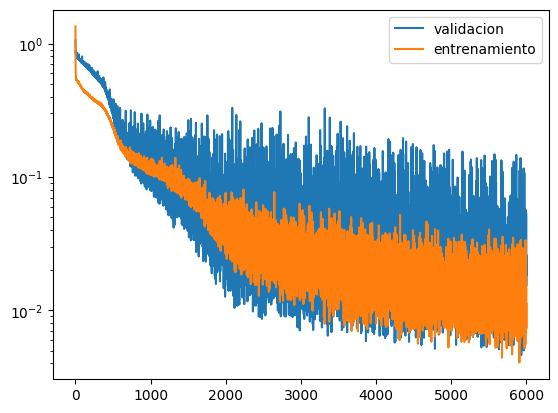

In [334]:
plt.plot(test_history, label="validacion")
plt.plot(history, label="entrenamiento")
plt.legend()
plt.yscale('log')

In [ ]:
with torch.no_grad():
    modelo_final.eval()
    y_pred = modelo_final(test_dataset[:][0]).cpu().numpy().squeeze()
plt.scatter(test_dataset[:][0], y_pred, label = "modelo final")
plt.scatter(xdata, ydata, color="black", label="Datos de prueba")
plt.legend()
plt.show()

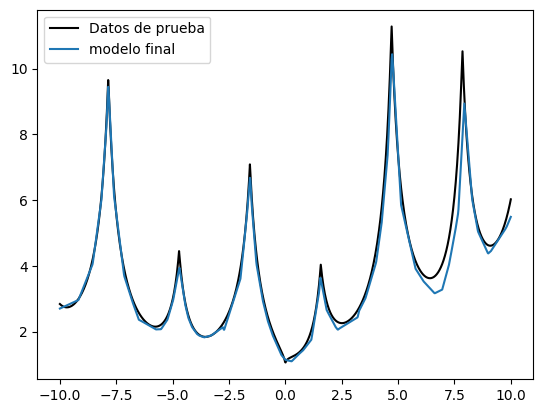

In [335]:
plt.plot(xdata, ydata, color="black", label="Datos de prueba")
with torch.no_grad():
    modelo_final.eval()
    y_pred = modelo_final(torch.tensor(xdata).float()).cpu().numpy().squeeze()
    plt.plot(xdata, y_pred, label = "modelo final")
plt.legend()

In [ ]:
# Guardar parametros del modelo (sin arquitectura)

torch.save(modelo_final.state_dict(), "modelo_final.pth")

# opcion guardar todo el modelo con arquitectura

torch.save(modelo_final, "modelo_completo.pth")